## Final Project - Analyzing the Impact of Recession on Automobile Sales
You have been hired by XYZAutomotives as a data scientist. Your first task is to analyze the historical data and give the company directors insights on how the sales were affected during times of recession. You will provide a number of charts/plots to visualize the data and make it easy for the directors to understand your analysis. 

**Data Description**

* The dataset includes the following variables:
    * Date: The month end date of sales observation.
    * Recession: A binary variable indicating recession perion; 1 means it was recession, 0 means it was normal.
    * Automobile_Sales: The number of vehicles sold during the period.
    * GDP: The per capita GDP value in USD.
    * Unemployment_Rate: The monthly unemployment rate.
    * Consumer_Confidence: A synthetic index representing consumer confidence, which can impact consumer spending and automobile purchases.
    * Seasonality_Weight: The weight representing the seasonality effect on automobile sales during the period. This variable represents the seasonal effect on automobile sales for a given month. * * In the automobile industry, sales often fluctuate throughout the year due to seasonal patterns—for example, sales may increase during the festive season or year-end promotions, and decrease during off-peak months like post-holiday winter periods.
        * A value greater than 1 indicates higher-than-average sales expected for that month due to seasonal trends (e.g., holiday season or new model launches).
        * A value less than 1 suggests lower-than-average sales due to seasonal slowdowns.
        * A value around 1 means the season has neutral or average effect on sales.
    * Price: The average vehicle price during the period.
    * Advertising_Expenditure: The advertising expenditure of the company.
    * Vehicle_Type: The type of vehicles sold; Supperminicar, Smallfamiliycar, Mediumfamilycar, Executivecar, Sports.
    * Competition: The measure of competition in the market, such as the number of competitors or market share of major manufacturers.
    * Month: Month of the observation extracted from Date.
    * Year: Year of the observation extracted from Date.

* By examining various factors mentioned above from the dataset, you aim to gain insights into how recessions impact automobile sales for your company.

* This Project will be completed in 2 Parts:
    * Part 1: Create Visualizations using Matplotlib, Seaborn & Folium
    * Part 2: Create Dashboard using Plotly and Dash

## **Create visualizations using Matplotib, Seaborn and Folium** 

In [12]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [13]:
df = pd.read_csv("data/automobile_sales.csv",date_format='%Y-%m-%d', parse_dates=["Date"])
print(df.dtypes)
df.head()

Date                       datetime64[us]
Year                                int64
Month                                 str
Recession                           int64
Consumer_Confidence               float64
Seasonality_Weight                float64
Price                               int64
Advertising_Expenditure           float64
Competition                         int64
GDP                               float64
Growth_Rate                       float64
unemployment_rate                 float64
Automobile_Sales                  float64
Vehicle_Type                          str
City                                  str
dtype: object


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


### TASK 1.1: Develop a *Line chart* using the functionality of pandas to show how Average automobile sales fluctuate from year to year

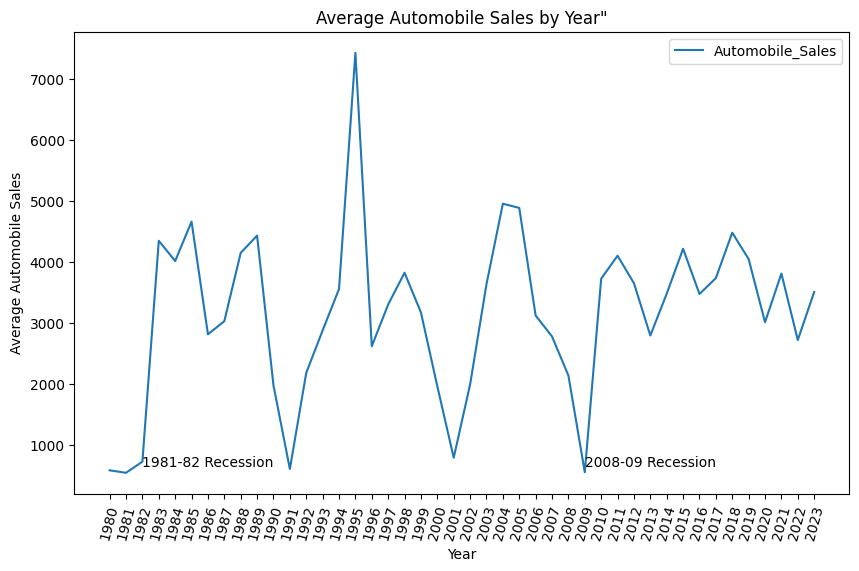

In [14]:
plt.figure(figsize=(10, 6))
df_line = df.groupby('Year')['Automobile_Sales'].mean()
df_line.plot(kind = 'line')
plt.xticks(list(range(1980,2024)), rotation = 75)
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales by Year"')
plt.text(1982, 650, '1981-82 Recession')
plt.text(2009, 650, '2008-09 Recession')
plt.legend()
plt.show()

####  TASK 1.2: How do trends in advertising expenditure correlate with automobile sales during non-recession periods, and what insights can be derived from this relationship.

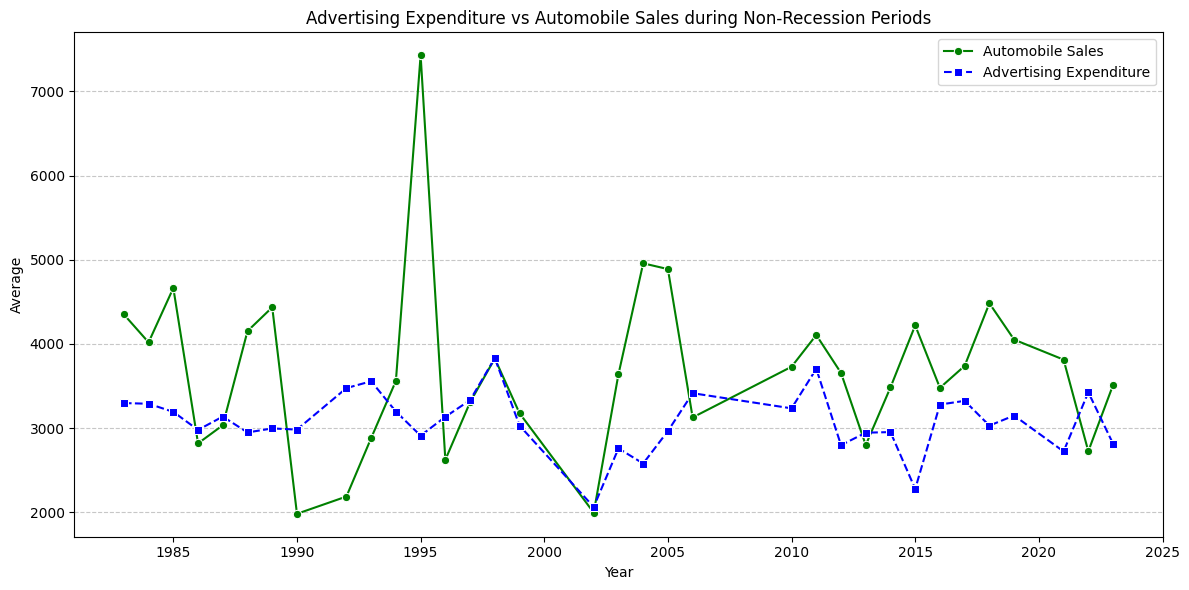

In [15]:
df_non_rec = df[df['Recession'] == 0]

# Calculate average automobile sales and average advertising expenditure by year (non-recession)
df_trends = df_non_rec.groupby('Year', as_index=False).agg(
    Avg_Sales=('Automobile_Sales', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)

# Create line plots for average sales and advertising expenditure over the years
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trends, x='Year', y='Avg_Sales', marker='o', linestyle='-', color='green', label='Automobile Sales')
sns.lineplot(data=df_trends, x='Year', y='Avg_Ad_Spend', marker='s', linestyle='--', color='blue', label='Advertising Expenditure')

# Add labels, legend, title, and grid
plt.xlabel('Year')
plt.ylabel('Average')
plt.title('Advertising Expenditure vs Automobile Sales during Non-Recession Periods')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

#### Inference

The graph shows that during non-recession periods, automobile sales are more volatile than advertising expenditure. While there are moments of alignment, sales often spike independently, suggesting other factors like market demand or economic conditions also play a significant role. The correlation between advertising and sales appears inconsistent over time.<br><br>


### TASK 1.3: Use the functionality of **Seaborn Library** to create a visualization to compare the sales trend per vehicle type for a recession period with a non-recession period.

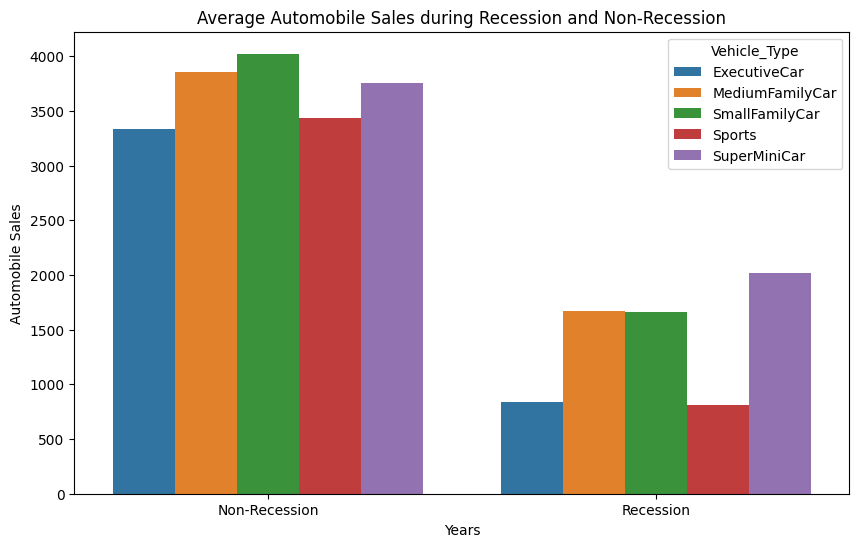

In [16]:
new_df = df.groupby(['Recession','Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

# Create the bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type',  data=new_df)
plt.xlabel('Years')
plt.ylabel('Automobile Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.show()

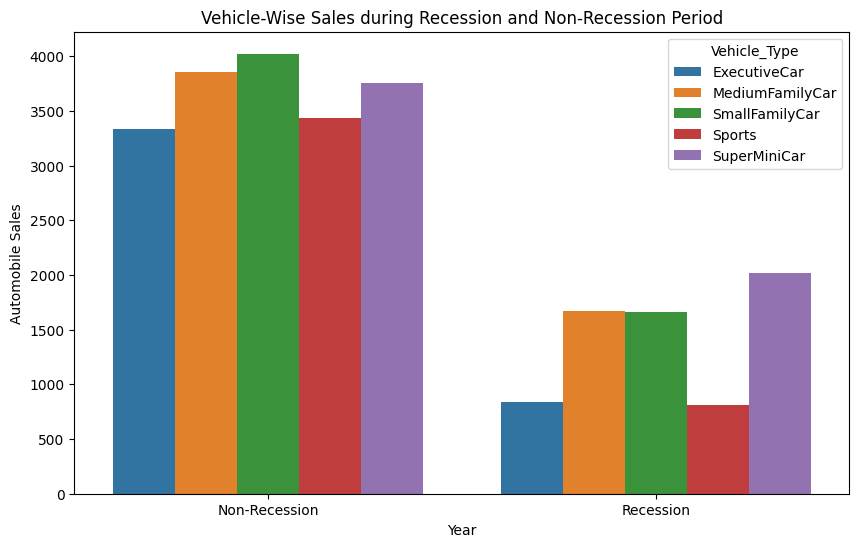

In [17]:
grouped_df = df.groupby(['Recession','Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

# Create the grouped bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=grouped_df)
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.xlabel('Year')
plt.ylabel('Automobile Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')

plt.show()

### Inference

From this plot, we can understand that there is a drastic decline in the overall sales of the automobiles during recession.<br>However, the most affected type of vehicle is executivecar and sports<br><br>

### TASK 1.4: Use sub plotting to compare the variations in GDP during recession and non-recession period by developing line plots for each period.
Now, you want to find more insights from the data to understand the reason. <br>Plot a two line charts using subplotting to answer:-
#### How did the GDP vary over time during recession and non-recession periods? 
<br>Make use of <u>add_subplot()</u> from Matplotlib for this comparision.

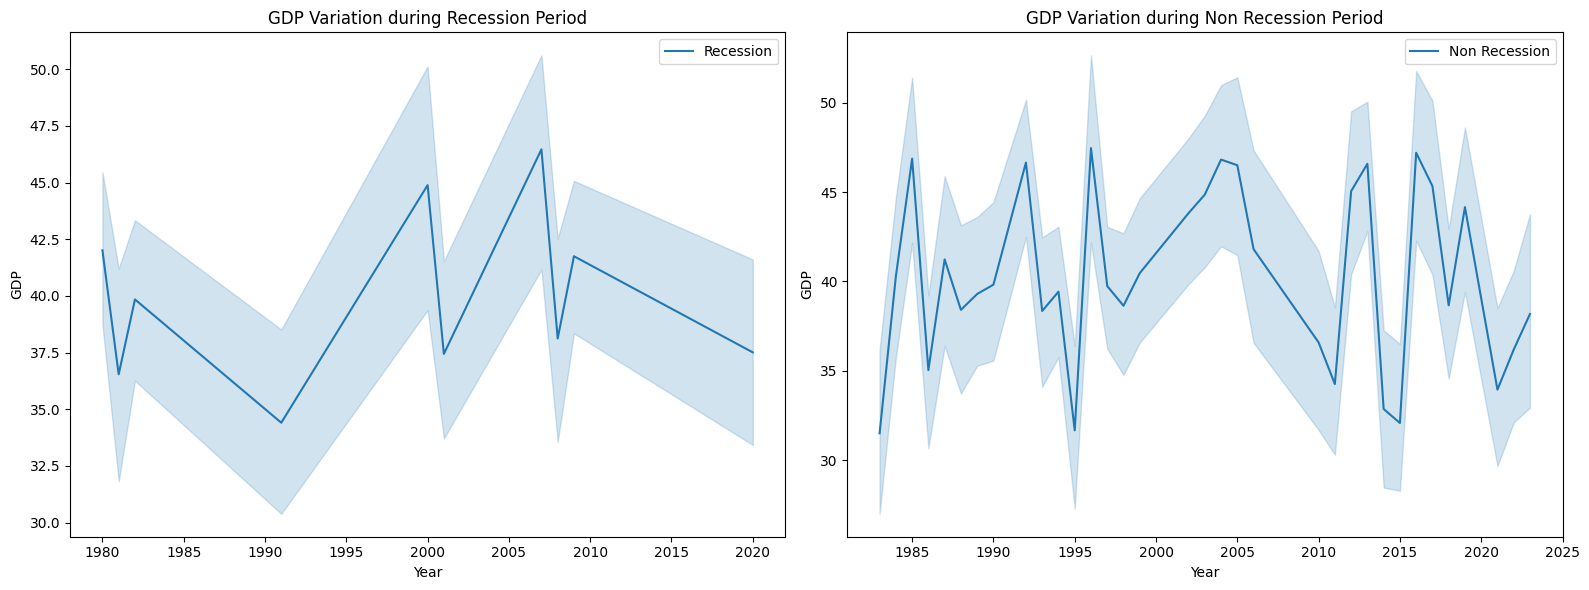

In [18]:
#Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

#Figure
fig=plt.figure(figsize=(16, 6))

#Create different axes for subploting
ax0 = fig.add_subplot(1, 2, 1) # add subplot 1 (1 row, 2 columns, first plot)
ax1 = fig.add_subplot(1, 2, 2) # add subplot 2 (1 row, 2 columns, second plot). 

#plt.subplot(1, 2, 1)
sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession', ax=ax0)
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
ax0.set_title('GDP Variation during Recession Period')

#plt.subplot(1, 2, 2)
sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='Non Recession',ax=ax1)
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
ax1.set_title('GDP Variation during Non Recession Period')

plt.tight_layout()
plt.show()

#### Alternatively...

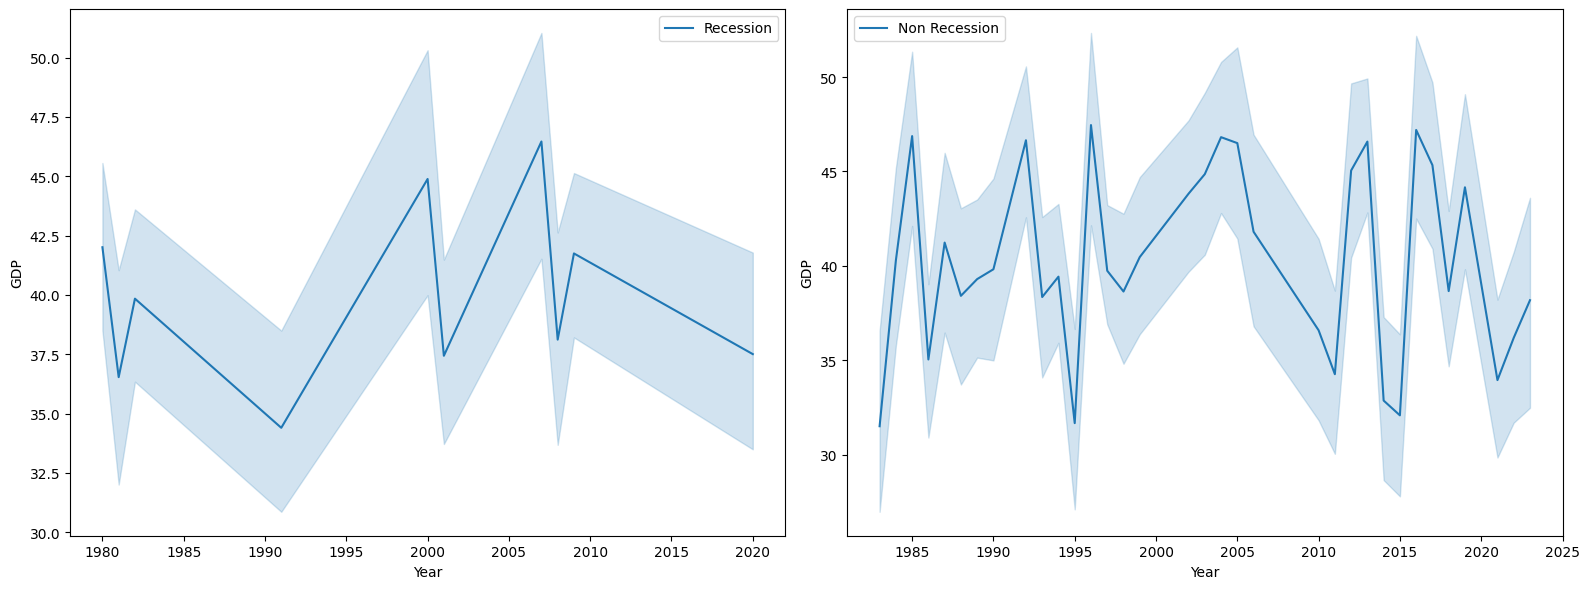

In [19]:
#------------------------------------------------Alternatively--------------
#Using subplot()
plt.figure(figsize=(16, 6))

#subplot 1
plt.subplot(1, 2, 1)
sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession')
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
plt.legend()
#subplot 2
plt.subplot(1, 2, 2)
sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='Non Recession')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
plt.legend()

plt.tight_layout()
plt.show()

#### Inference
From this plot, it is evident that GDP tends to be lower and more volatile during recessions, with significant fluctuations and uncertainty. In contrast, non-recessionary periods show a relatively higher GDP level but still exhibit some degree of variability.<br><br>

### TASK 1.5: Develop a Bubble plot for displaying the impact of seasonality on Automobile Sales.
<br>How has seasonality impacted the sales, in which months the sales were high or low? Check it for non-recession years to understand the trend

##### Develop a Bubble plot for displaying Automobile Sales for every month and use Seasonality Weight for representing the size of each bubble<br>
Title this plot as 'Seasonality impact on Automobile Sales'

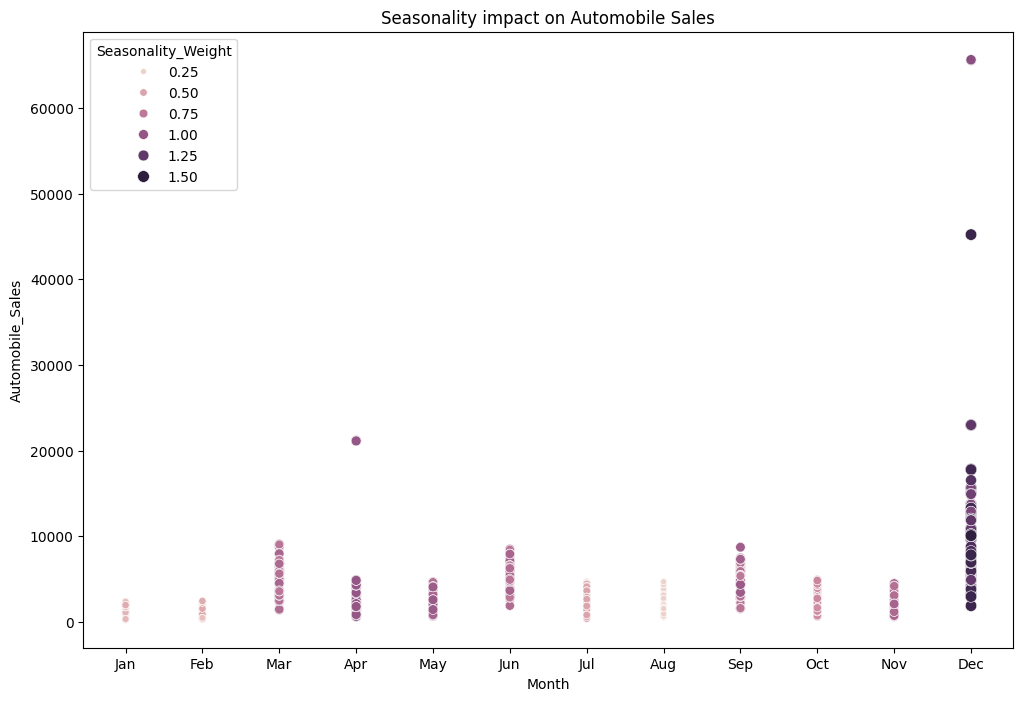

In [20]:
non_rec_data = df[df['Recession'] == 0]
size = non_rec_data['Seasonality_Weight'] #for bubble effect

plt.figure(figsize=(12,8))
sns.scatterplot(data=non_rec_data, x='Month', y='Automobile_Sales', size=size, hue='Seasonality_Weight', legend=True)
#you can further include hue='Seasonality_Weight', legend=False)
plt.xlabel('Month')
plt.ylabel('Automobile_Sales')
plt.title('Seasonality impact on Automobile Sales')
plt.show()

#### Inference
From this plot, it is evident that seasonality has not affected on the overall sales. However, there is a drastic raise in sales in the month of April and December<br><br>

 ### TASK 1.6: Use the functionality of Matplotlib to develop a scatter plot to identify the relationship between consumer confidence and automobile sales during recessions.
 #### From the data, develop a scatter plot to identify the relationship between consumer confidence and automobile sales during recession periods.
 <br> Title this plot as 'Consumer Confidence and Automobile Sales during Recessions'

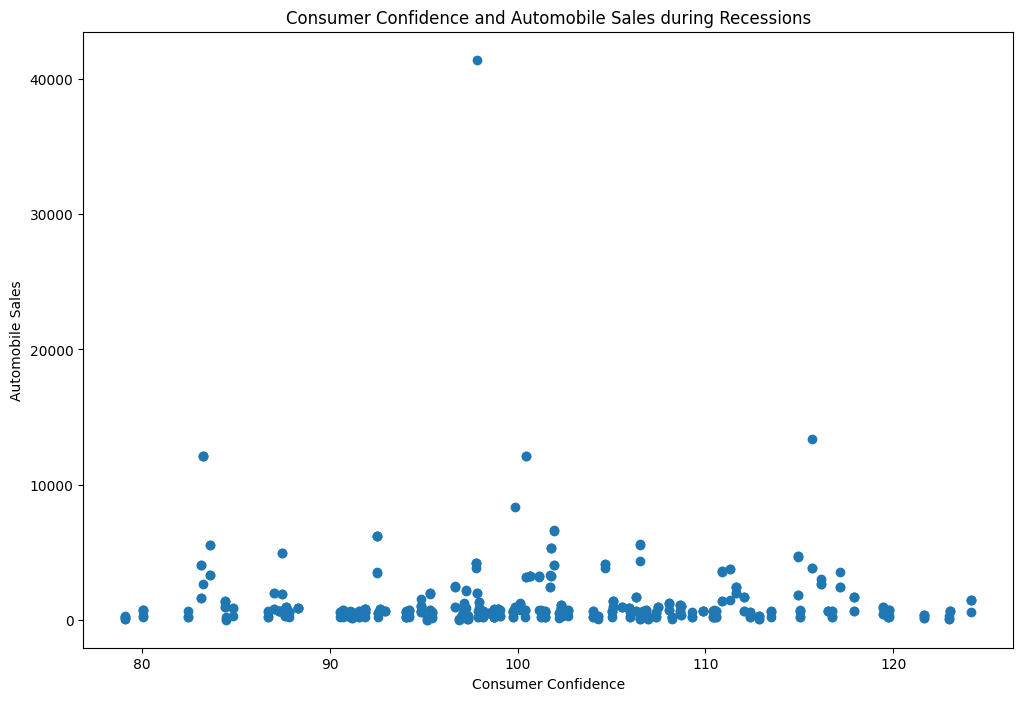

In [21]:
#Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]

plt.figure(figsize=(12,8))
plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'])
plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence and Automobile Sales during Recessions')
plt.show()

 ### How does consumer confidence relate to automobile sales during recessions?
 <br> Plot another scatter plot and title it as 'Relationship between Vehicle Price and Sales during Recessions'

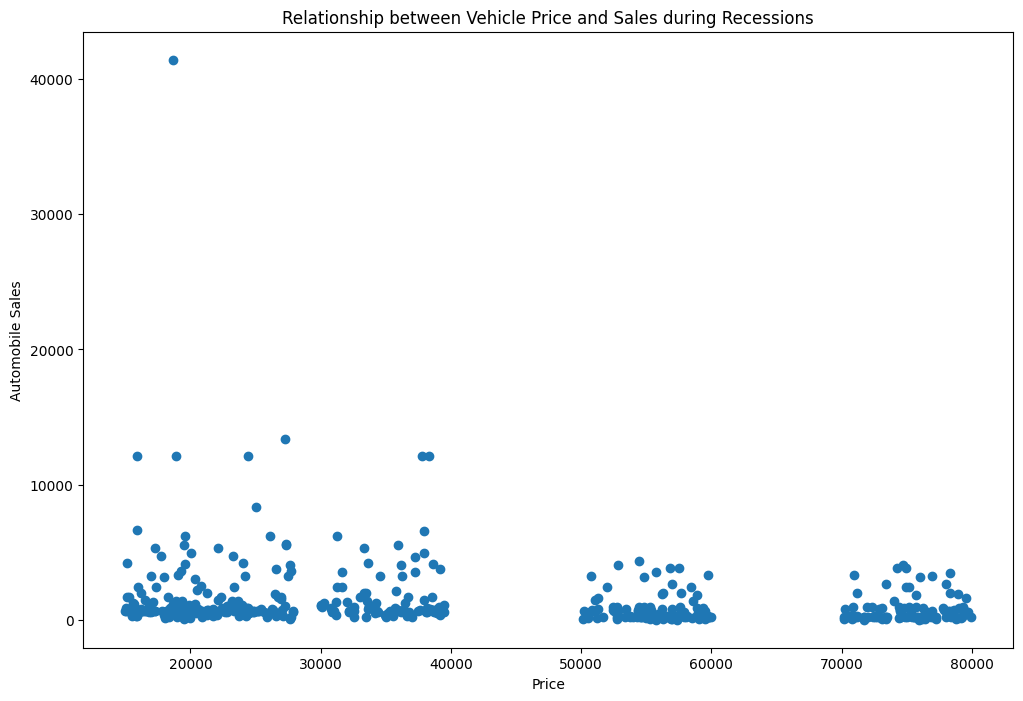

In [22]:
#Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]

plt.figure(figsize=(12,8))
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'])
plt.xlabel('Price')
plt.ylabel('Automobile Sales')
plt.title('Relationship between Vehicle Price and Sales during Recessions')
plt.show()

#### Inference
The graphs indicate that during recessions, higher consumer confidence tends to boost automobile sales, while higher vehicle prices generally correspond to lower sales. This highlights the strong influence of both consumer sentiment and affordability on purchasing decisions during economic downturns.<br><br>

 ### TASK 1.7: Create a pie chart to display the portion of advertising expenditure of XYZAutomotives during recession and non-recession periods.
 <br>How did the advertising expenditure of XYZAutomotives change during recession and non-recession periods? 

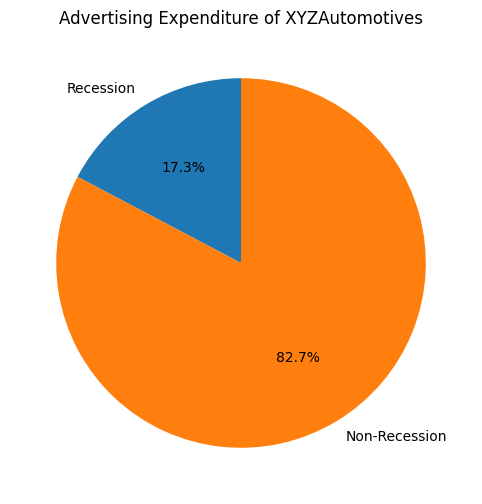

In [23]:
# Filter the data 
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

# Calculate the total advertising expenditure for both periods
RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()


# Create a pie chart for the advertising expenditure 
plt.figure(figsize=(8, 6))
labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Advertising Expenditure of XYZAutomotives')
plt.show()

#### Inference
It seems XYZAutomotives has been spending much more on the advertisements during non-recession periods as compared to during recession times. Fair enough!<br><br>

### TASK 1.8: Develop a pie chart to display the total Advertisement expenditure for each vehicle type during recession period.<br>
Can we observe the share of each vehicle type in total expenditure during recessions? 

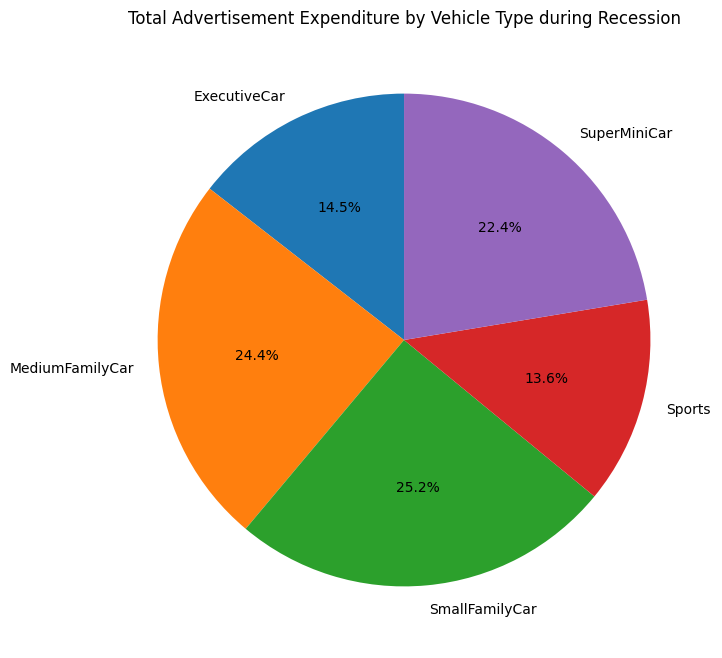

In [24]:
# Filter the data 
Rdata = df[df['Recession'] == 1]

# Calculate the sales volume by vehicle type during recessions
VTexpenditure = Rdata.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

# Create a pie chart for the share of each vehicle type in total expenditure during recessions
plt.figure(figsize=(10, 8))
labels = VTexpenditure.index
sizes = VTexpenditure.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Total Advertisement Expenditure by Vehicle Type during Recession')
plt.show()

#### Inference
During recession the advertisements were mostly focused on low price range vehicle. A wise decision!<br><br>

 ### TASK 1.9: Develop a lineplot to analyse the effect of the unemployment rate on vehicle type and sales during the Recession Period.
 Analyze the effect of the unemployment rate on vehicle type and sales during the Recession Period
 <BR>You can create a lineplot and title the plot as 'Effect of Unemployment Rate on Vehicle Type and Sales'

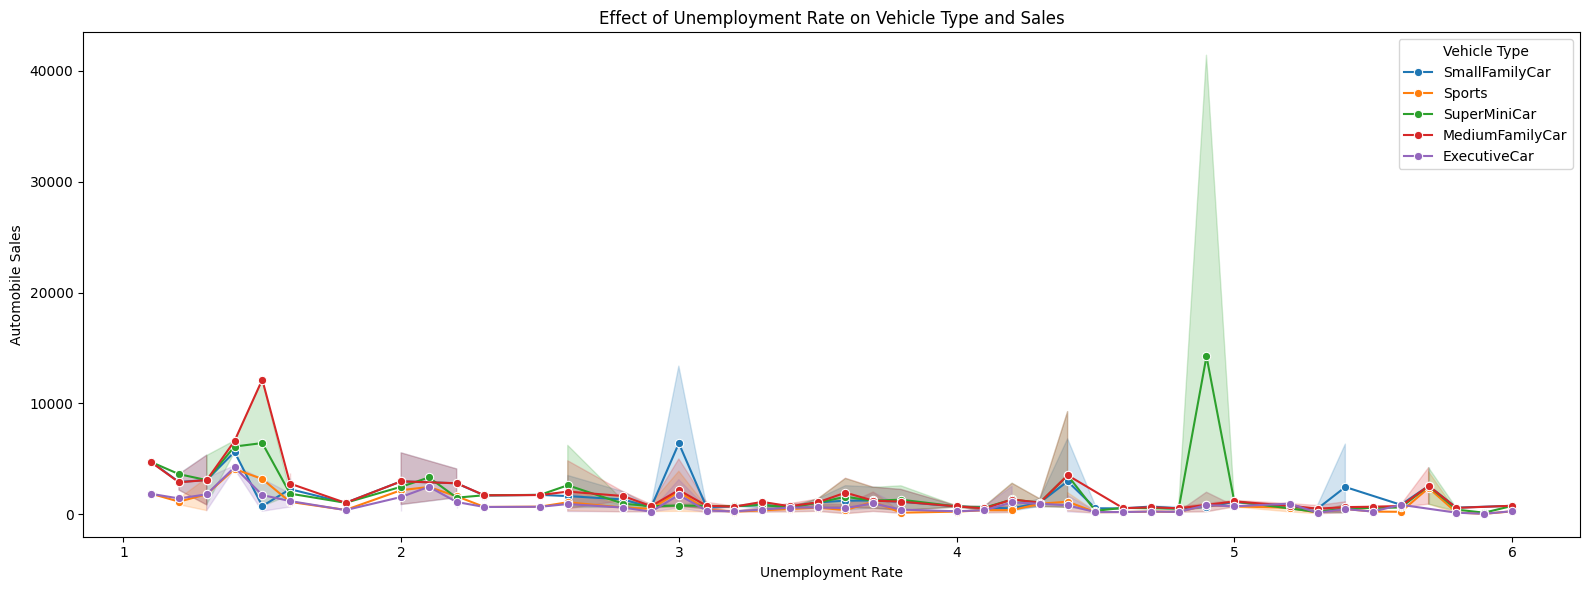

In [25]:
# Assuming 'df' is your dataset
df_rec = df[df['Recession'] == 1]

# Set figure size
plt.figure(figsize=(16, 6))
# Create line plot showing effect of unemployment rate on automobile sales, by vehicle type
sns.lineplot(
    data=df_rec,
    x='unemployment_rate',               # Replace with unemployment rate column (e.g., 'unemployment_rate')
    y='Automobile_Sales',               # Replace with automobile sales column (e.g., 'Automobile_Sales')
    hue='Vehicle_Type',             # Replace with vehicle type column (e.g., 'Vehicle_Type')
    marker='o'
)
# Customize labels, legend, and title
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.legend(title='Vehicle Type')
# Show plot
plt.tight_layout()
plt.show()

#### Inference
The plot shows that automobile sales decline as unemployment rates rise during a recession, with sharp drops beyond 3%. SuperMiniCars, SmallFamilyCars, and MediumFamilyCars exhibit high volatility, reflecting their sensitivity to economic uncertainty and changing consumer priorities.<br><br>

### TASK 1.10 Create a map on the highest sales region/offices of the company during recession period

You found that the datset also contains the location/city for company offices. Now you want to show the recession impact on various offices/city sales by developing a choropleth
'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/us-states.json'

In [26]:
# Filter the data for the recession period and specific cities
recession_data = df[df['Recession'] == 1]

# Calculate the total sales by city
sales_by_city = recession_data.groupby('City')['Automobile_Sales'].sum().reset_index()

# Create a base map centered on the United States
map1 = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

# Create a choropleth layer using Folium
choropleth = folium.Choropleth(
    geo_data= 'data/us-states.json',  # GeoJSON file with state boundaries
    data=sales_by_city,
    columns=['City', 'Automobile_Sales'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Automobile Sales during Recession'
).add_to(map1)


# Add tooltips to the choropleth layer
choropleth.geojson.add_child(
    folium.features.GeoJsonTooltip(['name'], labels=True)
)

# Display the map
map1